# 1. Introduction

In the era of modern e-commerce and digital marketing, understanding consumer purchasing behavior is serious for optimizing product placement, driving cross-selling strategies, and streamlining supply chain management. Association Rule Learning serves as a cornerstone unsupervised learning methodology. By conducting Market Basket Analysis on transactional logs, ARL uncovers hidden co-occurrence patterns and relationships among items purchased together within individual transactions.

### Dataset Architecture & Feature Overview
To conduct effective association rule mining, high-dimensional transaction logs must be structured into discrete "shopping baskets." The dataset provides key attributes that facilitate this transformation:
- InvoiceNo: A 6-digit integral number uniquely identifying each transaction basket. Transactions prefixed with 'C' denote cancellations, providing an avenue to analyze return behavior alongside positive purchases.

- StockCode & Description: Unique 5-digit inventory identifiers and qualitative product labels, respectively, used to represent individual items and evaluate frequent itemsets.

- Quantity & UnitPrice: Operational parameters measuring the volume of items per order and their retail prices, vital for filtering non-purchases ($Quantity \le 0$) and assessing the financial impact of mined rules.

- InvoiceDate: Precise transaction timestamps allowing for time-series segmentation and seasonal buying analysis.

- Country: Geographic tags identifying the origin of each customer, enabling market-specific behavioral comparisons across global regions.


### Analytical Objectives
By converting these transactional records into a standardized one-hot encoded matrix ($\text{Invoices} \times \text{Items}$), this project aims to achieve the following:
1. Extract Frequent Itemsets: Identify recurring item combinations that exceed pre-defined minimum Support thresholds.

2. Generate & Evaluate Rules: Filter rules using statistical metrics—specifically Confidence and Lift—to isolate strong, non-random purchasing associations ($A \rightarrow B$).

3. Derive Actionable Strategy: Translate algorithmic associations into business utility, such as designing effective product bundling options, optimizing inventory allocation for popular item pairs, and building data-driven cross-selling engines tailored for wholesale clients.

# 2. Inspecting the data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/online_retail.csv", index_col=0)

In [3]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
index,,,,,,,,
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France


I will have to convert the dates into datatime datatypes and tidy up the dataframe. I will only focus on the United Kingdom area as well as the valid transaction. I will remove cancelled, gift and negative quantity orders.

In [ ]:
# Convert date into appropriate format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [237]:
# Remove negative prices from the dataset
df = df[~(df["UnitPrice"] <0)]

In [238]:
# Only focus on the UK section
df = df[df["Country"] == "United Kingdom"]

In [239]:
# Remove cancelled orders
df["AbsQuantity"] = df["Quantity"].abs()

# sort, so we remove the previous transaction from the dataframe
df = df.sort_values(by=["CustomerID", "StockCode", "InvoiceDate"]).reset_index(drop=True)

# creating different dfs
pos_df = df[df["Quantity"] > 0].copy()
neg_df = df[df["Quantity"] < 0].copy()


pos_df["Pair_ID"] = pos_df.groupby(["CustomerID", "StockCode", "UnitPrice", "AbsQuantity"]).cumcount() # creates positive transaction 0,1,2,3
neg_df["Pair_ID"] = neg_df.groupby(["CustomerID", "StockCode", "UnitPrice", "AbsQuantity"]).cumcount() # creates negative transactions with 0,1,2 to help with merge


# this dataframe represent the transactions that were first bought then returned. so there is no profit from these
cancelled_pairs = pos_df.merge(
    neg_df[["CustomerID", "StockCode", "UnitPrice", "AbsQuantity", "Pair_ID"]],
    on=["CustomerID", "StockCode", "UnitPrice", "AbsQuantity", "Pair_ID"],
    how="inner"
)

pos_rows_to_drop = pos_df[
    pos_df.set_index(["CustomerID", "StockCode", "UnitPrice", "AbsQuantity", "Pair_ID"]).index.isin(
        cancelled_pairs.set_index(["CustomerID", "StockCode", "UnitPrice", "AbsQuantity", "Pair_ID"]).index
    )
].index


neg_rows_to_drop = neg_df.index

df_clean = df.drop(index=set(neg_rows_to_drop).union(set(pos_rows_to_drop)))
df_clean = df_clean.drop(columns=["AbsQuantity"])

In [240]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 483401 entries, 2 to 495475
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    483401 non-null  str           
 1   StockCode    483401 non-null  str           
 2   Description  482832 non-null  str           
 3   Quantity     483401 non-null  int64         
 4   InvoiceDate  483401 non-null  datetime64[us]
 5   UnitPrice    483401 non-null  float64       
 6   CustomerID   351855 non-null  float64       
 7   Country      483401 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.2 MB


In [ ]:
df_clean = df_clean.dropna(subset=["CustomerID", "Description"])

In [242]:
df_clean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2,545321,20711,JUMBO BAG TOYS,20,2011-03-01 14:53:00,1.95,12747.0,United Kingdom
3,537215,21136,PAINTED METAL PEARS ASSORTED,8,2010-12-05 15:38:00,1.69,12747.0,United Kingdom
4,541677,21136,PAINTED METAL PEARS ASSORTED,16,2011-01-20 14:01:00,1.69,12747.0,United Kingdom
5,545321,21136,PAINTED METAL PEARS ASSORTED,16,2011-03-01 14:53:00,1.69,12747.0,United Kingdom
6,551992,21136,PAINTED METAL PEARS ASSORTED,8,2011-05-05 15:31:00,1.69,12747.0,United Kingdom
...,...,...,...,...,...,...,...,...
361873,554065,85039B,S/4 IVORY MINI ROSE CANDLE IN BOWL,12,2011-05-22 10:39:00,1.65,18287.0,United Kingdom
361874,570715,85039B,S/4 IVORY MINI ROSE CANDLE IN BOWL,48,2011-10-12 10:23:00,1.45,18287.0,United Kingdom
361875,554065,85040A,S/4 PINK FLOWER CANDLES IN BOWL,36,2011-05-22 10:39:00,1.65,18287.0,United Kingdom
361876,554065,85040A,S/4 PINK FLOWER CANDLES IN BOWL,12,2011-05-22 10:39:00,1.65,18287.0,United Kingdom


In [243]:
# InvoiceNo -> clean, only contains numbers
df_clean[df_clean["InvoiceNo"].str.contains(r"^\d{6}$")]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2,545321,20711,JUMBO BAG TOYS,20,2011-03-01 14:53:00,1.95,12747.0,United Kingdom
3,537215,21136,PAINTED METAL PEARS ASSORTED,8,2010-12-05 15:38:00,1.69,12747.0,United Kingdom
4,541677,21136,PAINTED METAL PEARS ASSORTED,16,2011-01-20 14:01:00,1.69,12747.0,United Kingdom
5,545321,21136,PAINTED METAL PEARS ASSORTED,16,2011-03-01 14:53:00,1.69,12747.0,United Kingdom
6,551992,21136,PAINTED METAL PEARS ASSORTED,8,2011-05-05 15:31:00,1.69,12747.0,United Kingdom
...,...,...,...,...,...,...,...,...
361873,554065,85039B,S/4 IVORY MINI ROSE CANDLE IN BOWL,12,2011-05-22 10:39:00,1.65,18287.0,United Kingdom
361874,570715,85039B,S/4 IVORY MINI ROSE CANDLE IN BOWL,48,2011-10-12 10:23:00,1.45,18287.0,United Kingdom
361875,554065,85040A,S/4 PINK FLOWER CANDLES IN BOWL,36,2011-05-22 10:39:00,1.65,18287.0,United Kingdom
361876,554065,85040A,S/4 PINK FLOWER CANDLES IN BOWL,12,2011-05-22 10:39:00,1.65,18287.0,United Kingdom


In [244]:
# StockCode follows the rule of 5 digits and a letter if needed
df_clean = df_clean[df_clean["StockCode"].str.contains(r"(^\d{5}\w?$)")]

/var/folders/ft/mkxn4qpd7vdgfr1gm4t14r8h0000gn/T/ipykernel_88057/852978924.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_clean = df_clean[df_clean["StockCode"].str.contains(r"(^\d{5}\w?$)")]


In [245]:
# Quantity clean
df_clean[df_clean["Quantity"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [246]:
df_clean[df_clean["CustomerID"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [247]:
# CustomerID follows the 5 digit pattern
df_clean[~df_clean["CustomerID"].astype("str").str.contains(r"\d{5}")]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [248]:
df_clean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2,545321,20711,JUMBO BAG TOYS,20,2011-03-01 14:53:00,1.95,12747.0,United Kingdom
3,537215,21136,PAINTED METAL PEARS ASSORTED,8,2010-12-05 15:38:00,1.69,12747.0,United Kingdom
4,541677,21136,PAINTED METAL PEARS ASSORTED,16,2011-01-20 14:01:00,1.69,12747.0,United Kingdom
5,545321,21136,PAINTED METAL PEARS ASSORTED,16,2011-03-01 14:53:00,1.69,12747.0,United Kingdom
6,551992,21136,PAINTED METAL PEARS ASSORTED,8,2011-05-05 15:31:00,1.69,12747.0,United Kingdom
...,...,...,...,...,...,...,...,...
361873,554065,85039B,S/4 IVORY MINI ROSE CANDLE IN BOWL,12,2011-05-22 10:39:00,1.65,18287.0,United Kingdom
361874,570715,85039B,S/4 IVORY MINI ROSE CANDLE IN BOWL,48,2011-10-12 10:23:00,1.45,18287.0,United Kingdom
361875,554065,85040A,S/4 PINK FLOWER CANDLES IN BOWL,36,2011-05-22 10:39:00,1.65,18287.0,United Kingdom
361876,554065,85040A,S/4 PINK FLOWER CANDLES IN BOWL,12,2011-05-22 10:39:00,1.65,18287.0,United Kingdom


# Converting into occurance dataframe

In [249]:
df_clean['Description'] = df_clean['Description'].astype(str).str.strip()

In [250]:
basket = (df_clean.groupby(["InvoiceNo", "Description"])["Quantity"]
    .sum()
    .unstack(fill_value=0)
)

In [251]:
basket

Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581582,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
581583,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
581584,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [252]:
basket_encoded = basket > 0

In [261]:
basket_encoded.head()

Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536366,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536367,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536368,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536369,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# Running the algorithm

This is the part where the data mining occurs. The model will first find the most frequent items purchused and add them to the frequent_items dataframe. Then from these instances the algorithm will generate rules. These rules include the support, confidance and the lift.

In [254]:
from mlxtend.frequent_patterns import apriori, association_rules

In [255]:
frequent_items = apriori(
    basket_encoded,
    min_support=0.01,
    use_colnames=True
)

In [256]:
frequent_items

,support,itemsets
0,0.011784,frozenset({10 COLOUR SPACEBOY PEN})
1,0.010751,frozenset({12 MESSAGE CARDS WITH ENVELOPES})
2,0.015125,frozenset({12 PENCIL SMALL TUBE WOODLAND})
3,0.017069,frozenset({12 PENCILS SMALL TUBE RED RETROSPOT})
4,0.016522,frozenset({12 PENCILS SMALL TUBE SKULL})
...,...,...
972,0.010569,"frozenset({WHITE HANGING HEART T-LIGHT HOLDER,..."
973,0.010326,"frozenset({WOODEN TREE CHRISTMAS SCANDINAVIAN,..."
974,0.011905,"frozenset({REGENCY CAKESTAND 3 TIER, ROSES REG..."
975,0.011237,"frozenset({LUNCH BAG RED RETROSPOT, LUNCH BAG ..."


The frequent_items dataframe contains the most purchased goods in the transaction rows.  10 Colour Spaceboy Pen is in the transaction of about 1.17% of the times and so on.

In [275]:
rules = association_rules(
    frequent_items, 
    metric="lift", 
    min_threshold=1.0
)

rules['antecedents'] = rules['antecedents'].apply(lambda x: ''.join(list(x))) # remove commas from the names of the products
rules['consequents'] = rules['consequents'].apply(lambda x: ''.join(list(x)))

rules["rule"] = rules["antecedents"] + (" -> ") + rules["consequents"]

Here I created the rules and saved these into a new dataframe called rules.

In [278]:
rules.sort_values(by="confidence", ascending=False).head(5)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,rule
155,HERB MARKER THYME,HERB MARKER ROSEMARY,0.010873,0.010934,0.010205,0.938547,85.840596,1.0,0.010086,16.094808,0.999215,0.879581,0.937868,0.935940,HERB MARKER THYME -> HERB MARKER ROSEMARY
154,HERB MARKER ROSEMARY,HERB MARKER THYME,0.010934,0.010873,0.010205,0.933333,85.840596,1.0,0.010086,14.836907,0.999276,0.879581,0.932601,0.935940,HERB MARKER ROSEMARY -> HERB MARKER THYME
153,HERB MARKER PARSLEY,HERB MARKER ROSEMARY,0.010751,0.010934,0.010022,0.932203,85.260358,1.0,0.009905,14.588729,0.999012,0.859375,0.931454,0.924435,HERB MARKER PARSLEY -> HERB MARKER ROSEMARY
948,WOODEN TREE CHRISTMAS SCANDINAVIANWOODEN HEART...,WOODEN STAR CHRISTMAS SCANDINAVIAN,0.011116,0.024358,0.010326,0.928962,38.138397,1.0,0.010055,13.734042,0.984726,0.410628,0.927188,0.676451,WOODEN TREE CHRISTMAS SCANDINAVIANWOODEN HEART...
152,HERB MARKER ROSEMARY,HERB MARKER PARSLEY,0.010934,0.010751,0.010022,0.916667,85.260358,1.0,0.009905,11.870983,0.999196,0.859375,0.915761,0.924435,HERB MARKER ROSEMARY -> HERB MARKER PARSLEY


Then I sorted these rules by confidence. Just to mention a one. 
- If someone buys Herb Marker Thyme (antecedents) then it has 93% probability (confidence) that the customer will also buy the Herb Marker Rosemary (consequents).

- For this rule the support means that this purchuse was found to occur 1% among all of the transactions. 

- Lift measures how much more likely item B is bought when item A is present, compared to item B's baseline popularity across all orders. A Lift of 85.8 means a customer who buys Herb Marker Thyme is 85 times more likely to buy Herb Marker Rosemary than a random customer browsing the store.


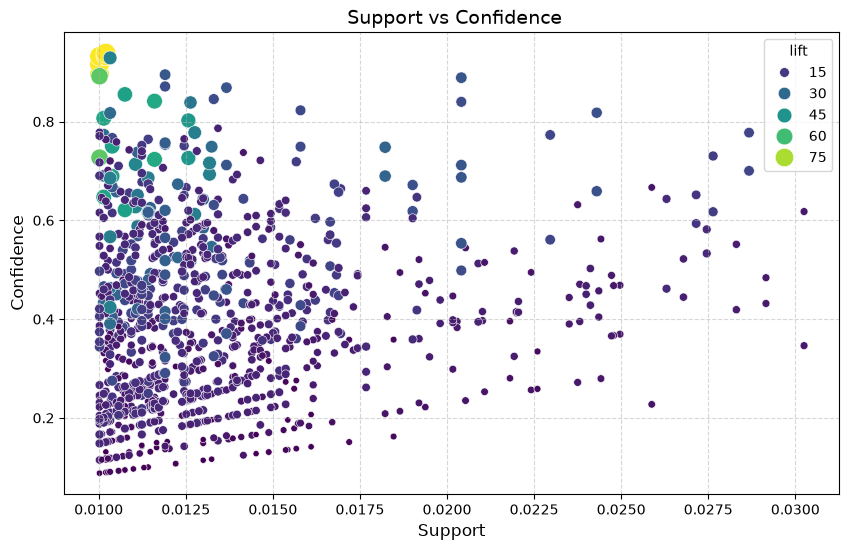

In [259]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rules,
    x="support",
    y="confidence",
    hue="lift",
    size="lift",
    palette="viridis",
    sizes=(20, 200)
)

plt.title(" Support vs Confidence", fontsize=14)
plt.xlabel("Support", fontsize=12)
plt.ylabel("Confidence", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

The plot above represents a 2d visualisation about the rules found by the algorithm. The size and color difference represents the lift of the rules.
A clear positive releationship is visible between support and confidence. Also where the lift is high (yellow big circles) the support tends to be small. Altough the rule is strong, the overall occurance in the transactions is small. Personally I would focus on the right up corner, where support is high and confidence is high as well.

In [277]:
import plotly.express as px

fig = px.scatter_3d(
    rules,
    x="support",
    y="confidence",
    z="lift",
    color="lift",
    size="lift",
    size_max=18,
    hover_name="rule",
    hover_data={
        "support": ":.4f",
        "confidence": ":.4f",
        "lift": ":.2f"
    },
    color_continuous_scale="Viridis",
    title="3D Association Rules: Support vs Confidence vs Lift"
)

# 3. Clean up axis labels and layout padding
fig.update_layout(
    scene=dict(
        xaxis_title="Support",
        yaxis_title="Confidence",
        zaxis_title="Lift"
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

This is the 3d representation of the 2d plot above. It is reactive so it is possible to inspect the regions and view the rules itself if hovered on the circle.

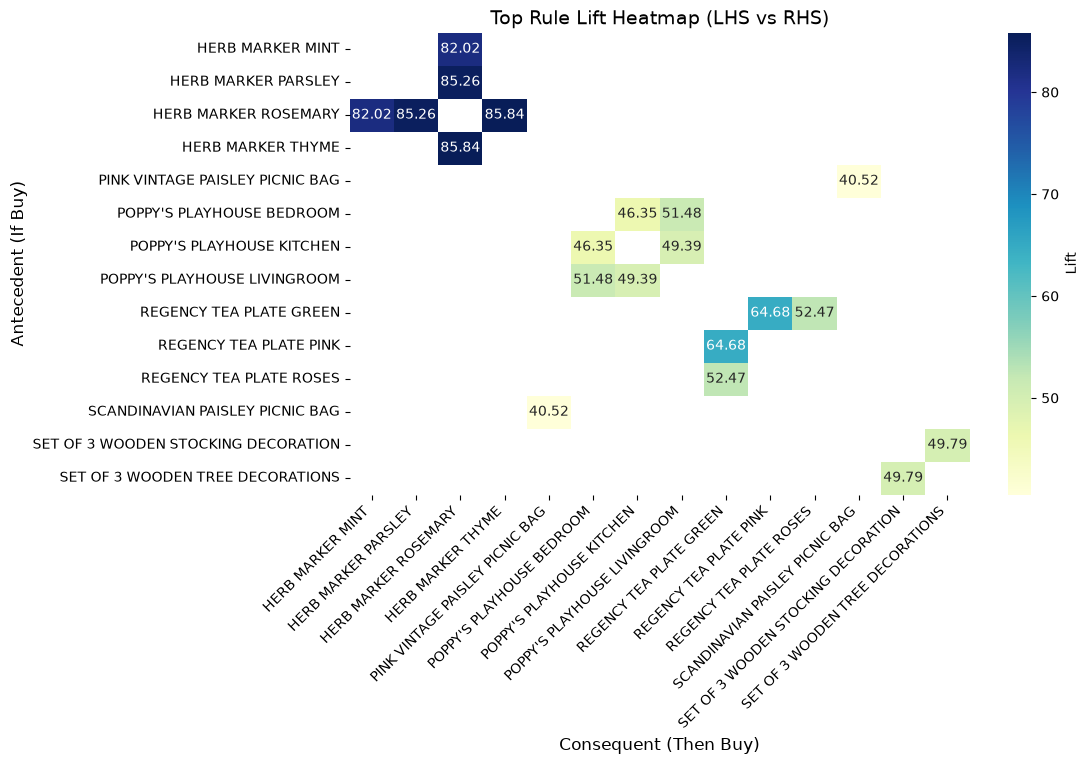

In [266]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Take top 20 rules
top_20 = rules.sort_values(by="lift", ascending=False).head(20)

# 2. Pivot matrix: Antecedent (rows) vs Consequent (columns)
pivot = top_20.pivot(index='antecedents', columns='consequents', values='lift')

# 3. Plot Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Lift'})
plt.title("Top Rule Lift Heatmap (LHS vs RHS)", fontsize=14)
plt.xlabel("Consequent (Then Buy)", fontsize=12)
plt.ylabel("Antecedent (If Buy)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

The heatmap plot represents the same lift information what 3d and 2d plots showed but in a different way. Clearly visible that the Herb Markers are bought together as well as Poppy`s playing sets.

# What to do with these rules?

In order to avoid leaving the consequents on the shelves we should aim the minimize the friction when it comes to purhcusing to increase average order value. That is, the goods that have a high lift and confidence should be packed on the same shelves if its in a retail store. If its an online store then we should upsell and offer them the consequents when the antecedents are added to the basket. Altough these rules were trivial, where Herb Markers are have a high lift, we should dig deep down into the rules dataset and find other relationships that are not straighforward. There might be a case where someone purchusing butter increases the probability of buying yoghurt. Once a rule is identified, it should be implemented by putting these goods close to each other.